<a href="https://colab.research.google.com/github/SawyerKaye/CYSE635/blob/main/Shapley_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sawyer Kaye

# Libraries and data loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.data import Dataset
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import shap

In [4]:
data = pd.read_csv('drive/My Drive/diabetes.csv')

# Data Exploration/Preprocessing

In [5]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.size

6912

In [7]:
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


<Axes: >

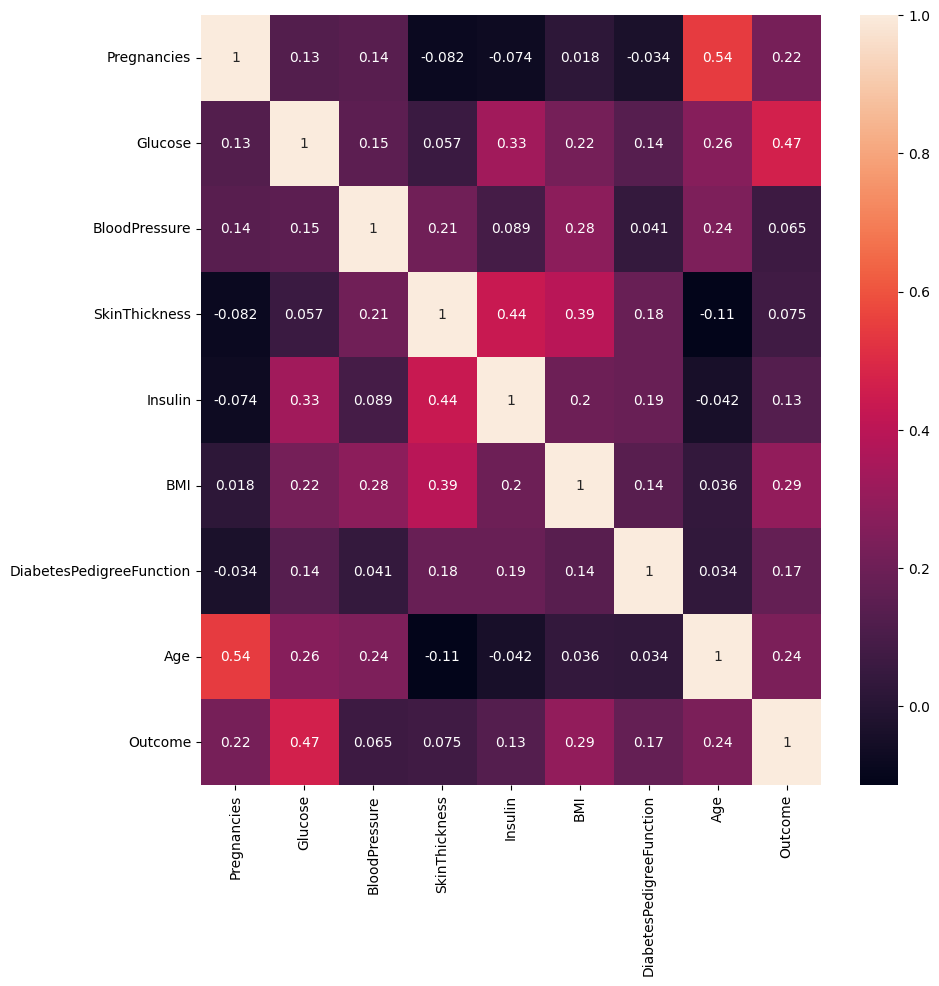

In [8]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot=True)

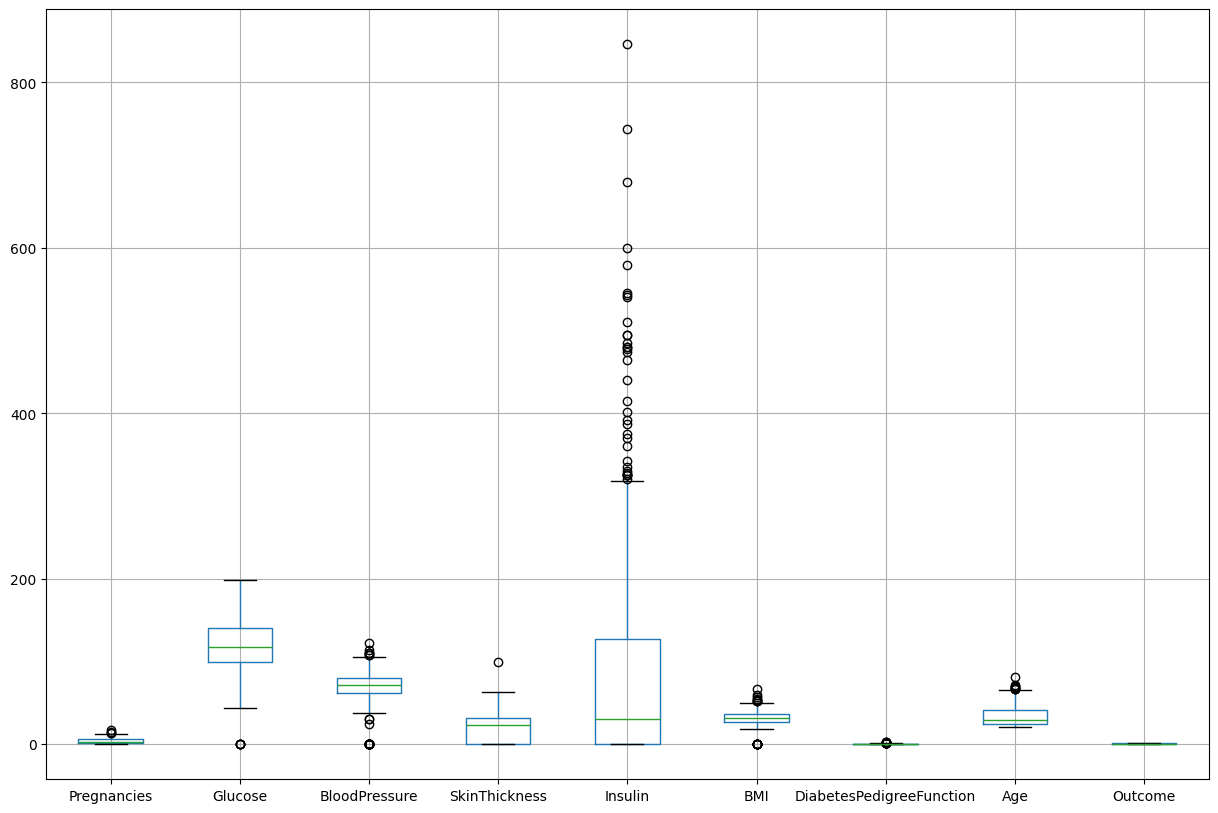

In [9]:
plt.figure(figsize=(15, 10))
data.boxplot()
plt.show()

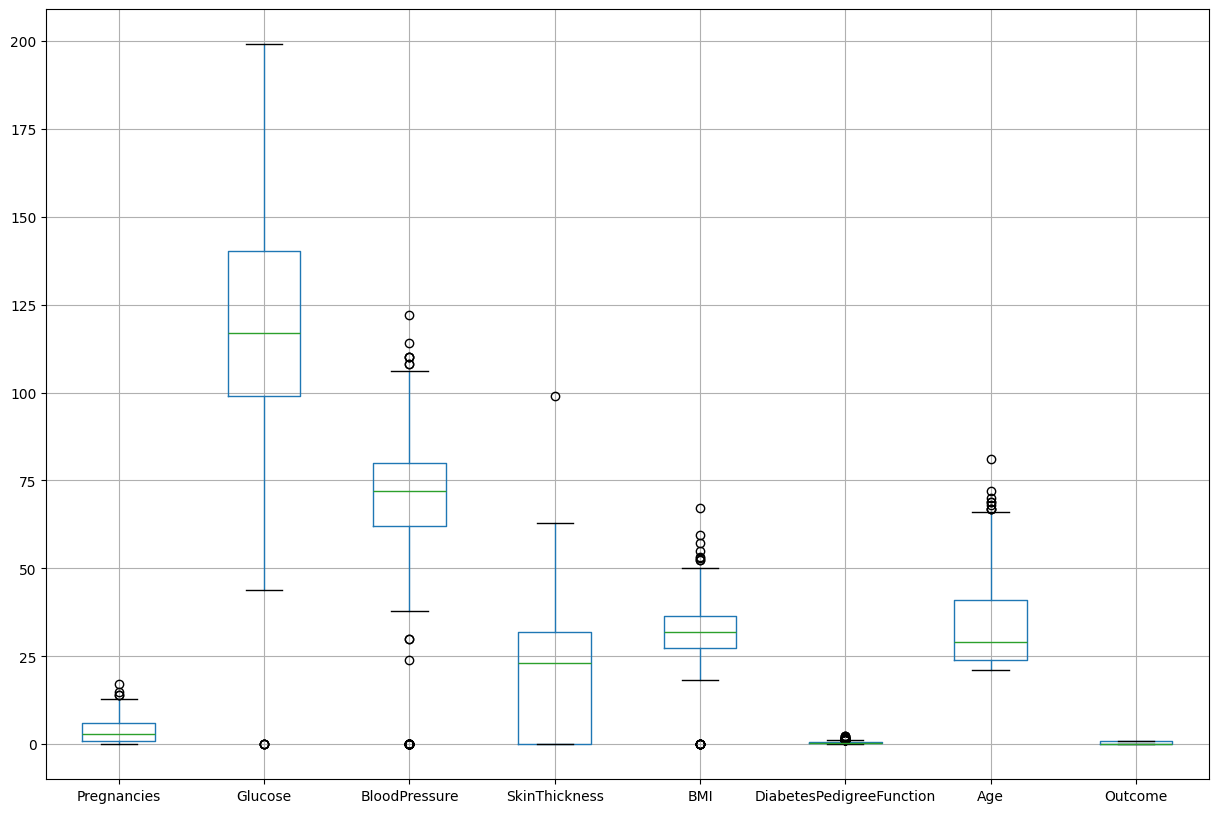

In [10]:
plt.figure(figsize=(15, 10))
data.drop(['Insulin'],axis=1).boxplot()
plt.show()

In [11]:
q1 = data.quantile(0.01)
q3 = data.quantile(0.97)

In [12]:
data = data[~((data < (q1)) |(data > (q3))).any(axis=1)]

In [13]:
data.size

5391

# Splitting the Data

In [14]:
#X = data.drop(['Outcome', 'BloodPressure', 'SkinThickness', 'DiabetesPedigreeFunction', 'Pregnancies', 'Age'],axis=1)
X = data.drop(['Outcome'],axis=1)
Y = data['Outcome']

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=41)

Intentionally not using scaling as I found model performance decreased with it for this situation. Most likely could be optimized to provide benefit for the future.

In [16]:
#standscal = StandardScaler()
#X_train = standscal.fit_transform(X_train)
#X_test = standscal.transform(X_test)

In [17]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
594,6,123,72,45,230,33.6,0.733,34
73,4,129,86,20,270,35.1,0.231,23
79,2,112,66,22,0,25.0,0.307,24
315,2,112,68,22,94,34.1,0.315,26
633,1,128,82,17,183,27.5,0.115,22
...,...,...,...,...,...,...,...,...
302,5,77,82,41,42,35.8,0.156,35
467,0,97,64,36,100,36.8,0.600,25
173,1,79,60,42,48,43.5,0.678,23
151,4,114,65,0,0,21.9,0.432,37


# Implementing multiple ML models

In [18]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, Y_train)
y_pred = dtc.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.775


In [19]:
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train, Y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.8083333333333333


In [20]:
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, Y_train)
y_pred = rfc.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.8


In [21]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

y_pred = lr.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.8166666666666667


In [22]:
svc = SVC(kernel='linear')
svc.fit(X_train, Y_train)
y_pred = svc.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.8083333333333333


In [23]:
gnb = GaussianNB()
gnb.fit(X_train, Y_train)
y_pred = gnb.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.7833333333333333


# Moving forward with Logistic Regression, using SHAP

In [24]:
def model_proba(x):
    return lr.predict_proba(x)[:, 1]


def model_log_odds(x):
    p = lr.predict_log_proba(x)
    return p[:, 1] - p[:, 0]

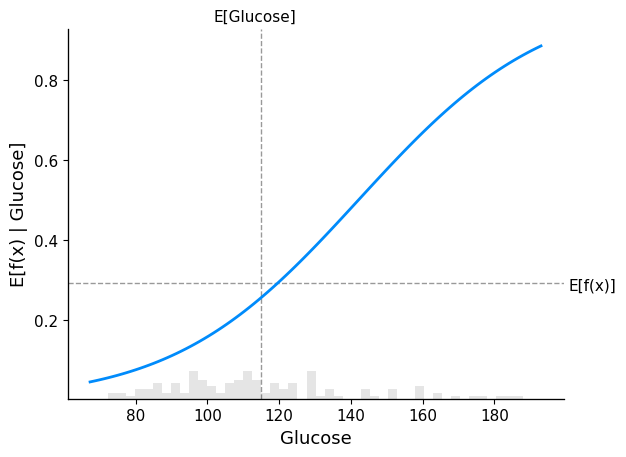

In [25]:
# make a standard partial dependence plot
sample_ind = 18
fig, ax = shap.partial_dependence_plot(
    "Glucose",
    model_proba,
    X_test,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

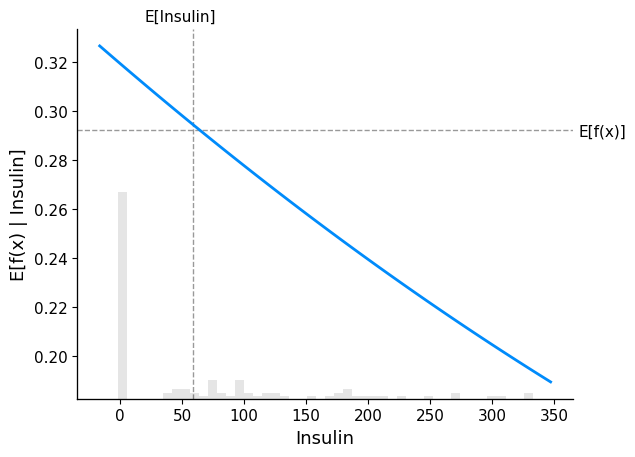

In [26]:
sample_ind = 18
fig, ax = shap.partial_dependence_plot(
    "Insulin",
    model_proba,
    X_test,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ice=False,
)

In [27]:
background = shap.maskers.Independent(X_test, max_samples=100)
explainer = shap.Explainer(model_proba, background)
shap_values = explainer(X_test[:300])

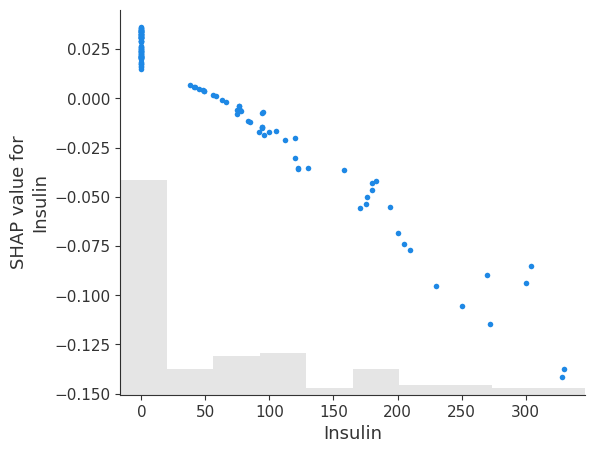

In [28]:
shap.plots.scatter(shap_values[:, "Insulin"])

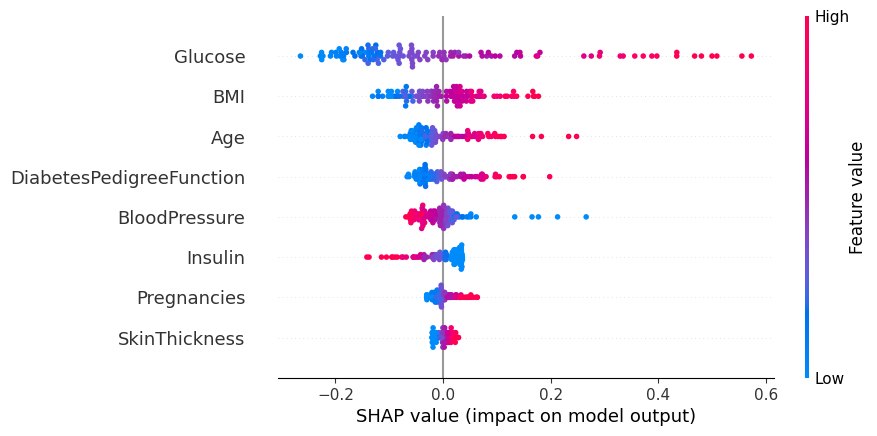

In [29]:
shap.plots.beeswarm(shap_values)

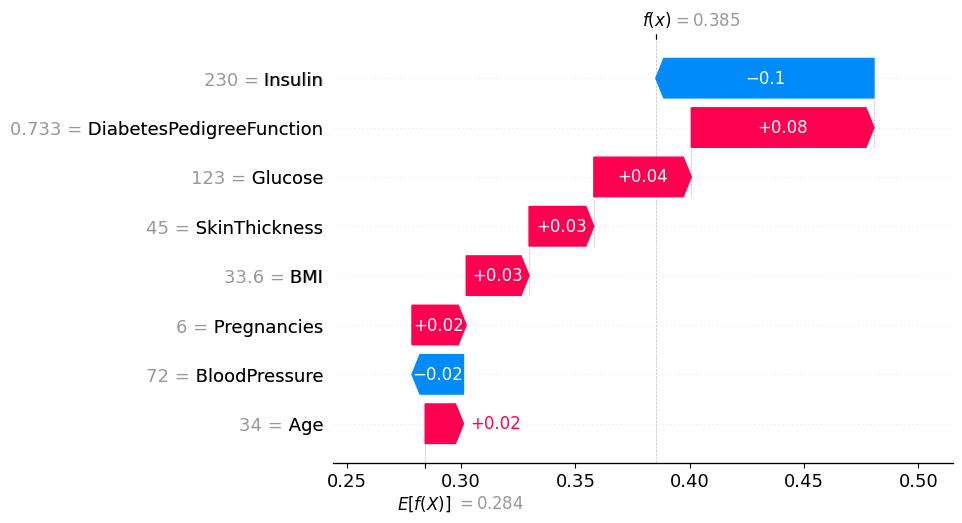

In [30]:
shap.plots.waterfall(shap_values[0])

# Reevaluating after SHAP

In [43]:
X = data.drop(['Outcome', 'SkinThickness','Pregnancies', 'BloodPressure', 'Age','DiabetesPedigreeFunction'],axis=1)
Y = data['Outcome']

In [44]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=41)

In [45]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

y_pred = lr.predict(X_test)
acc = accuracy_score(Y_test, y_pred)
print(acc)

0.8583333333333333


In [46]:
cm = confusion_matrix(Y_test, y_pred)

Text(0.5, 1.0, 'Confusion Matrix for Logistic Regression model on Pima Indians Diabetes Dataset')

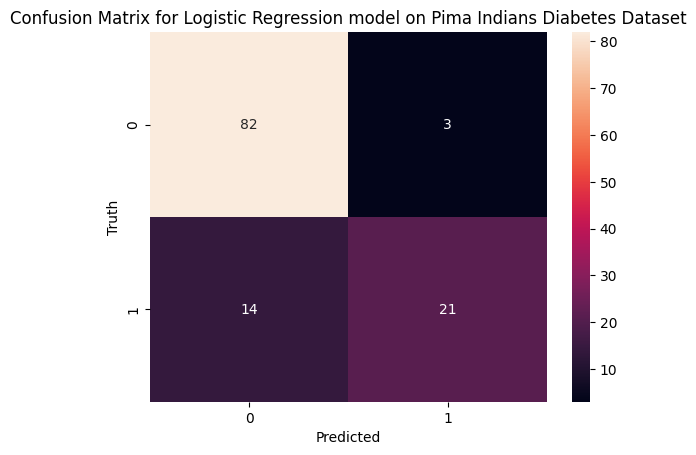

In [49]:
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title("Confusion Matrix for Logistic Regression model on Pima Indians Diabetes Dataset")

In [48]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.96      0.91        85
           1       0.88      0.60      0.71        35

    accuracy                           0.86       120
   macro avg       0.86      0.78      0.81       120
weighted avg       0.86      0.86      0.85       120



# Sources

Shap documentation - https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

GeeksforGeeks for refresher on scikit learn syntax

Course discussions